<a href="https://colab.research.google.com/github/duckmaster168/Research_MPGELU_Testing_Students/blob/main/Test_1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchinfo

In [ ]:
import os
import sys
from pathlib import Path

#PyTorch
import torch as torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
import time
from torchinfo import summary

import pandas as pd
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import random
from typing import Iterable, Callable


#sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Import torchvision
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchinfo import summary

#Import tqdm for a cool progress bar
from tqdm.auto import tqdm

# Measure time
from timeit import default_timer as timer

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)


print(f"PyTorch Version: {torch.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"SciPy Version: {scipy.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch Version: 2.11.0+cu128
Numpy Version: 2.1.3
Pandas Version: 2.2.3
Matplotlib Version: 3.10.0
SciPy Version: 1.16.3


In [ ]:
### Add the parent directory to the sys.path to import MyCNN and MPGELU
path1  = str(Path.cwd().parents[0])
if path1 not in sys.path:
    sys.path.append(path1)

In [ ]:
from MPGELU import MPGELU
from PGELU import PGELU
from MyCNN import MyCNN
from DataTransforms import DataTransforms
from Trainer import Trainer

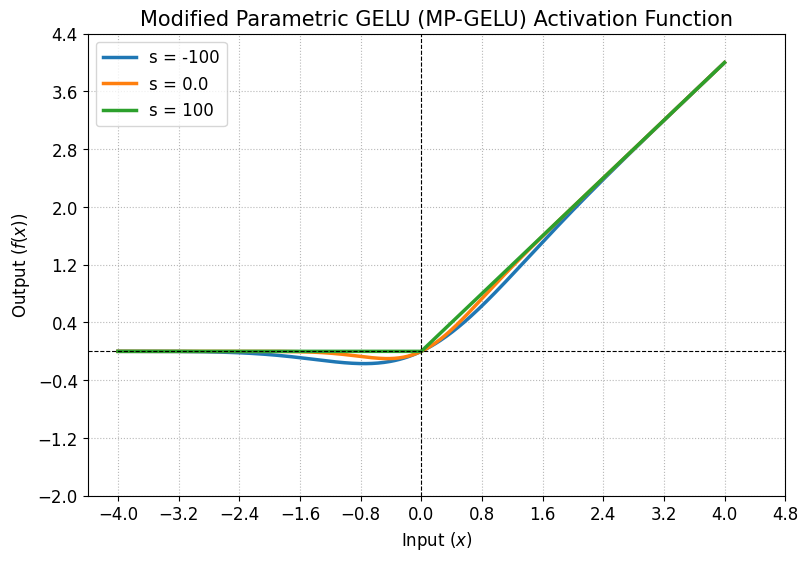

In [ ]:
x_np = np.linspace(-4.0, 4.0, 400)
x_tensor = torch.tensor(x_np, dtype=torch.float32)
# s_values = np.arange(-2.0, 2.0, 0.1)
s_values = [-100, 0.0, 100, ]
plt.figure(figsize=(9, 6))

for s_val in s_values:
    activation1 = MPGELU(s_param=s_val)
    activation2 = MPGELU(s_param=s_val, use_softplus=False)
    with torch.no_grad():
        y_tensor1 = activation1(x_tensor)
        y_tensor2 = activation2(x_tensor)

    lam_val = (1.0 + F.softplus(torch.tensor(s_val, dtype=torch.float32))).item()
    plt.plot(x_np, y_tensor1.numpy(), label=f"s = {s_val}", linewidth=2.5)
    # plt.plot(x_np, y_tensor2.numpy(), label=f"s = {s_val}", linewidth=2)

# 4. Format the plot
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Modified Parametric GELU (MP-GELU) Activation Function", fontsize=15)
xticks = np.arange(-4, 5, 0.8)
plt.xticks(xticks,fontsize=12)
plt.xlabel("Input ($x$)", fontsize=12)
yticks = np.arange(-2, 5, 0.8)
plt.yticks(yticks,fontsize=12)
plt.ylabel("Output ($f(x)$)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.9)
plt.legend(fontsize=12)
plt.show()

In [ ]:
transformer = DataTransforms(dataset='cifar10', use_augmentation=True, use_stats=False)
train_transform = transformer.get_train_transform()
test_transform = transformer.get_test_transform()


train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)


train_dataloader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [26:45<00:00, 106kB/s]


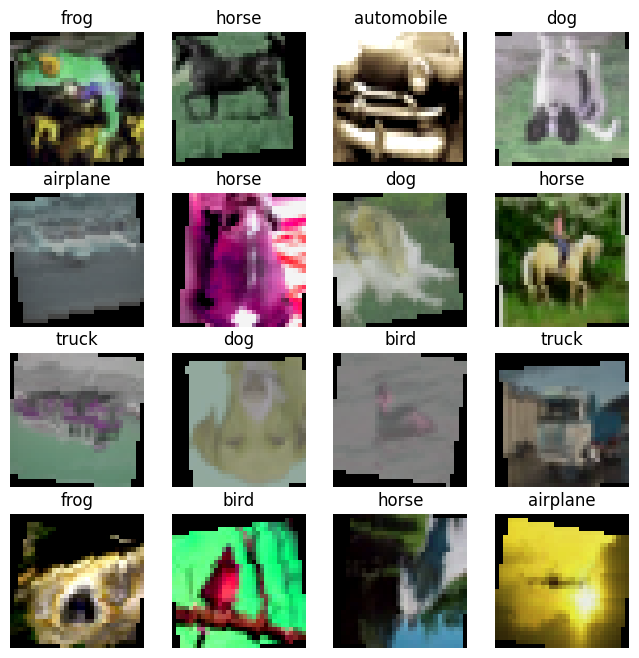

In [ ]:

fig = plt.figure(figsize=(8, 8))
rows, columns = 4, 4

for i in range(1, rows * columns + 1):
    idx = torch.randint(0, len(train_data), size=[1]).item()  # Random index
    img, label = train_data[idx][0], train_data[idx][1]
    fig.add_subplot(rows, columns, i)

    # Display image without converting to grayscale
    plt.imshow(img.permute(1, 2, 0))  # Change channels to last dimension (H, W, C)
    plt.title(train_data.classes[label])
    plt.grid(False)
    plt.axis(False)

plt.axis(False)
# plt.savefig("cifar10_dataset.jpg",dpi=800, bbox_inches="tight")
plt.show()

In [ ]:

chosen_model_params = [32, 32, 32, 'MaxPool', 64, 64, 'MaxPool', 128, 128, 128, 'MaxPool']

model = MyCNN(input_shape=3,
                  output_shape=10,
                  activation = MPGELU,
                  params = chosen_model_params).to(device)

print(summary(model=model,
        input = torch.randn(size=(3, 32, 32)).unsqueeze(dim=0)))

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Layer (type:depth-idx)                   Param #
MyCNN                                    --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       896
│    └─MPGELU: 2-2                       1
│    └─Conv2d: 2-3                       9,248
│    └─MPGELU: 2-4                       1
│    └─Conv2d: 2-5                       9,248
│    └─MPGELU: 2-6                       1
│    └─MaxPool2d: 2-7                    --
│    └─Conv2d: 2-8                       18,496
│    └─MPGELU: 2-9                       1
│    └─Conv2d: 2-10                      36,928
│    └─MPGELU: 2-11                      1
│    └─MaxPool2d: 2-12                   --
│    └─Conv2d: 2-13                      73,856
│    └─MPGELU: 2-14                      1
│    └─Conv2d: 2-15                      147,584
│    └─MPGELU: 2-16                      1
│    └─Conv2d: 2-17                      147,584
│    └─MPGELU: 2-18                      1
│    └─MaxPool2d: 2-19                   --
├─Sequ

In [ ]:
dummy_input = torch.randn(1, 3, 32, 32).to(device)
model(dummy_input)

tensor([[-0.0471, -0.0164,  0.0130,  0.0156,  0.0138, -0.0072,  0.0174,  0.0473,
         -0.0024,  0.0315]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
#Setup Loss Functions, Accuracy function
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

#Define Accuracy Metric
def calculate_accuracy(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  accuracy = (correct / len(y_pred)) * 100
  return accuracy

##Training Parameters

num_of_epochs = 60
num_loss_steps = 5

In [ ]:
activation_dict = {
    "MP_GELU": MPGELU,
    "PGELU": PGELU,
    "ReLU": torch.nn.ReLU,
    "GELU": torch.nn.GELU,
    "LeakyReLU": torch.nn.LeakyReLU
}

all_results = {}

for act_name, act_fn in activation_dict.items():
    print(f"\n=======================================================")
    print(f"       TRAINING WITH ACTIVATION: {act_name}")
    print(f"=======================================================")

    model = MyCNN(input_shape=3, output_shape=10, activation=act_fn, params=chosen_model_params).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

    trainer = Trainer(model=model, loss_fn=loss_fn, optimizer=optimizer,
                      calculate_accuracy=calculate_accuracy, device=device, loss_steps=num_loss_steps)

    results = {
        "train_loss": [],
        "train_accu": [],
        "test_loss": [],
        "test_accu": [],
        "activation_params": {}
    }

    start_time = time.perf_counter()

    for epoch in tqdm(range(num_of_epochs), desc=f"Training {act_name}"):
        if epoch % num_loss_steps == 0:
            print(f"Epoch: {epoch} \n =====================================================================")
        train_loss, train_accu = trainer.train(data_loader=train_dataloader, epoch=epoch)
        test_loss, test_accu = trainer.test(data_loader=test_dataloader, epoch=epoch)

        results["train_loss"].append(train_loss)
        results["train_accu"].append(train_accu)
        results["test_loss"].append(test_loss)
        results["test_accu"].append(test_accu)

        # Track dynamic activation parameters
        for name, param in model.named_parameters():
            if 'alpha_param' in name or 'beta_param' in name or 's_param' in name:
                if name not in results.setdefault("activation_params", {}):
                    results["activation_params"][name] = []
                results["activation_params"][name].append(param.item())

    total_time = time.perf_counter() - start_time
    results["total_runtime"] = total_time
    all_results[act_name] = results

    # Save Model Checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'results': results,
        'total_runtime': total_time,
        'activation_name': act_name
    }

    save_dir = "model_trained_params"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"chkpt_{act_name}.pth")

    torch.save(checkpoint, save_path)
    print(f"Saved model state to {save_path}")


       TRAINING WITH ACTIVATION: MP_GELU


Training MP_GELU:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 2.11773 | Training Accuracy: 22.27701%
Test Loss 1.82709 | Test Accuracy 37.99446%
Epoch: 5 
Training Loss: 1.29384 | Training Accuracy: 64.37420%
Test Loss 1.10419 | Test Accuracy 74.10997%
Epoch: 10 
Training Loss: 1.11111 | Training Accuracy: 73.04028%
Test Loss 0.99600 | Test Accuracy 78.70847%
Epoch: 15 
Training Loss: 1.02250 | Training Accuracy: 76.84942%
Test Loss 0.92037 | Test Accuracy 82.35759%
Epoch: 20 
Training Loss: 0.97079 | Training Accuracy: 79.38979%
Test Loss 0.88204 | Test Accuracy 83.67286%
Epoch: 25 
Training Loss: 0.93689 | Training Accuracy: 80.92152%
Test Loss 0.86104 | Test Accuracy 84.58267%
Epoch: 30 
Training Loss: 0.90829 | Training Accuracy: 82.13915%
Test Loss 0.85177 | Test Accuracy 85.15625%
Epoch: 35 
Training Loss: 0.89901 | Training Accuracy: 82.53197%
Test Loss 0.83937 | Test Accuracy 85.34415%
Epoch: 40 
Training Loss: 0.87377 | Training Accuracy: 83.70884%
Test Loss 0.82571 | Test Accuracy 86.69897%
Epoch: 45 
Training L

Training PGELU:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 2.06565 | Training Accuracy: 24.99680%
Test Loss 1.71612 | Test Accuracy 43.31487%
Epoch: 5 
Training Loss: 1.29342 | Training Accuracy: 64.81897%
Test Loss 1.10813 | Test Accuracy 74.57476%
Epoch: 10 
Training Loss: 1.17025 | Training Accuracy: 70.73729%
Test Loss 1.00213 | Test Accuracy 79.01503%
Epoch: 15 
Training Loss: 1.10218 | Training Accuracy: 73.79276%
Test Loss 0.95240 | Test Accuracy 80.78521%
Epoch: 20 
Training Loss: 1.07007 | Training Accuracy: 75.16664%
Test Loss 0.93295 | Test Accuracy 81.81369%
Epoch: 25 
Training Loss: 1.03738 | Training Accuracy: 76.77470%
Test Loss 0.90820 | Test Accuracy 82.84217%
Epoch: 30 
Training Loss: 1.01633 | Training Accuracy: 77.73418%
Test Loss 0.94515 | Test Accuracy 81.66535%
Epoch: 35 
Training Loss: 0.98913 | Training Accuracy: 78.98098%
Test Loss 0.89243 | Test Accuracy 83.67286%
Epoch: 40 
Training Loss: 0.97245 | Training Accuracy: 79.62716%
Test Loss 0.86316 | Test Accuracy 84.96835%
Epoch: 45 
Training L

...

Epoch: 0 
Training Loss: 2.15357 | Training Accuracy: 20.09831%
Test Loss 1.92227 | Test Accuracy 32.95095%
Epoch: 5 
Training Loss: 1.58162 | Training Accuracy: 49.69190%
Test Loss 1.38635 | Test Accuracy 59.31566%
Epoch: 10 
Training Loss: 1.35919 | Training Accuracy: 60.74608%
Test Loss 1.20058 | Test Accuracy 68.69066%
Epoch: 15 
Training Loss: 1.25893 | Training Accuracy: 65.58384%
Test Loss 1.11868 | Test Accuracy 72.60680%
Epoch: 20 
Training Loss: 1.18878 | Training Accuracy: 69.06010%
Test Loss 1.05358 | Test Accuracy 75.91970%
Epoch: 25 
Training Loss: 1.15398 | Training Accuracy: 70.84839%
Test Loss 1.03901 | Test Accuracy 76.29549%
Epoch: 30 
Training Loss: 1.12085 | Training Accuracy: 71.99968%
Test Loss 1.00078 | Test Accuracy 78.62935%
Epoch: 35 
Training Loss: 1.10094 | Training Accuracy: 73.09383%
Test Loss 1.01284 | Test Accuracy 77.35364%
Epoch: 40 
Training Loss: 1.08139 | Training Accuracy: 74.21076%
Test Loss 0.98306 | Test Accuracy 78.95570%
Epoch: 45 
Training L

Training GELU:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 2.13030 | Training Accuracy: 21.74073%
Test Loss 1.85884 | Test Accuracy 35.21559%
Epoch: 5 
Training Loss: 1.34169 | Training Accuracy: 62.26423%
Test Loss 1.14403 | Test Accuracy 71.44976%
Epoch: 10 
Training Loss: 1.15914 | Training Accuracy: 70.78844%
Test Loss 1.00706 | Test Accuracy 78.79747%
Epoch: 15 
Training Loss: 1.07478 | Training Accuracy: 74.85854%
Test Loss 0.95931 | Test Accuracy 80.72587%
Epoch: 20 
Training Loss: 1.02458 | Training Accuracy: 77.17991%
Test Loss 0.92578 | Test Accuracy 81.94225%
Epoch: 25 
Training Loss: 0.98747 | Training Accuracy: 78.83152%
Test Loss 0.88810 | Test Accuracy 83.83109%
Epoch: 30 
Training Loss: 0.95933 | Training Accuracy: 80.11709%
Test Loss 0.88919 | Test Accuracy 83.76187%
Epoch: 35 
Training Loss: 0.93464 | Training Accuracy: 81.26798%
Test Loss 0.85932 | Test Accuracy 84.82991%
Epoch: 40 
Training Loss: 0.91479 | Training Accuracy: 82.10398%
Test Loss 0.84340 | Test Accuracy 85.62104%
Epoch: 45 
Training L

Training LeakyReLU:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 2.12100 | Training Accuracy: 22.05563%
Test Loss 1.85738 | Test Accuracy 35.52215%
Epoch: 5 
Training Loss: 1.47044 | Training Accuracy: 55.50352%
Test Loss 1.29417 | Test Accuracy 63.77571%
Epoch: 10 
Training Loss: 1.23066 | Training Accuracy: 67.18630%
Test Loss 1.12596 | Test Accuracy 72.58703%
Epoch: 15 
Training Loss: 1.11902 | Training Accuracy: 72.46603%
Test Loss 0.98978 | Test Accuracy 78.81725%
Epoch: 20 
Training Loss: 1.05610 | Training Accuracy: 75.36565%
Test Loss 0.96199 | Test Accuracy 80.30063%
Epoch: 25 
Training Loss: 1.01927 | Training Accuracy: 77.28101%
Test Loss 0.94548 | Test Accuracy 81.33900%
Epoch: 30 
Training Loss: 0.98636 | Training Accuracy: 78.71324%
Test Loss 0.90980 | Test Accuracy 82.66416%
Epoch: 35 
Training Loss: 0.96758 | Training Accuracy: 79.53844%
Test Loss 0.89974 | Test Accuracy 83.00040%
Epoch: 40 
Training Loss: 0.94835 | Training Accuracy: 80.53109%
Test Loss 0.88345 | Test Accuracy 83.82120%
Epoch: 45 
Training L